# Phase 2: Incident & Availability Analysis
In this phase, we analyze downtime impact, incident trends, and track SLA compliance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")

# Create output directories
os.makedirs('../reports/charts', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

## Task 1 — Downtime Impact Analysis

In [2]:
# Load datasets
df_incidents = pd.read_csv('../data/raw/incidents.csv')
df_services = pd.read_csv('../data/raw/services.csv')

# Merge incidents with service data
df_merged = pd.merge(df_incidents, df_services, on='service_id', how='left')

# Calculate downtime hours
df_merged['downtime_hours'] = df_merged['downtime_minutes'] / 60.0

# Assign severity weights and impact score
severity_weights = {'P1': 4, 'P2': 3, 'P3': 2, 'P4': 1}
df_merged['severity_weight'] = df_merged['severity'].map(severity_weights)
df_merged['business_impact_score'] = df_merged['downtime_minutes'] * df_merged['severity_weight']

# Summary by Service
service_summary = df_merged.groupby('service_name').agg(
    total_downtime_minutes=('downtime_minutes', 'sum'),
    total_downtime_hours=('downtime_hours', 'sum'),
    avg_downtime_per_incident=('downtime_minutes', 'mean'),
    total_impact_score=('business_impact_score', 'sum'),
    service_tier=('service_tier', 'first')
).reset_index().sort_values('total_downtime_hours', ascending=False)

print(service_summary.head())

             service_name  total_downtime_minutes  total_downtime_hours  \
6    Notification Service                    6542            109.033333   
4                     EHR                    5830             97.166667   
5         Lab Results API                    5270             87.833333   
3       Claims Processing                    4908             81.800000   
1  Authentication Service                    4735             78.916667   

   avg_downtime_per_incident  total_impact_score service_tier  
6                  94.811594               16700          low  
4                  97.166667               16989     critical  
5                  90.862069               13896     standard  
3                  72.176471               11397     critical  
1                  73.984375               12052     critical  


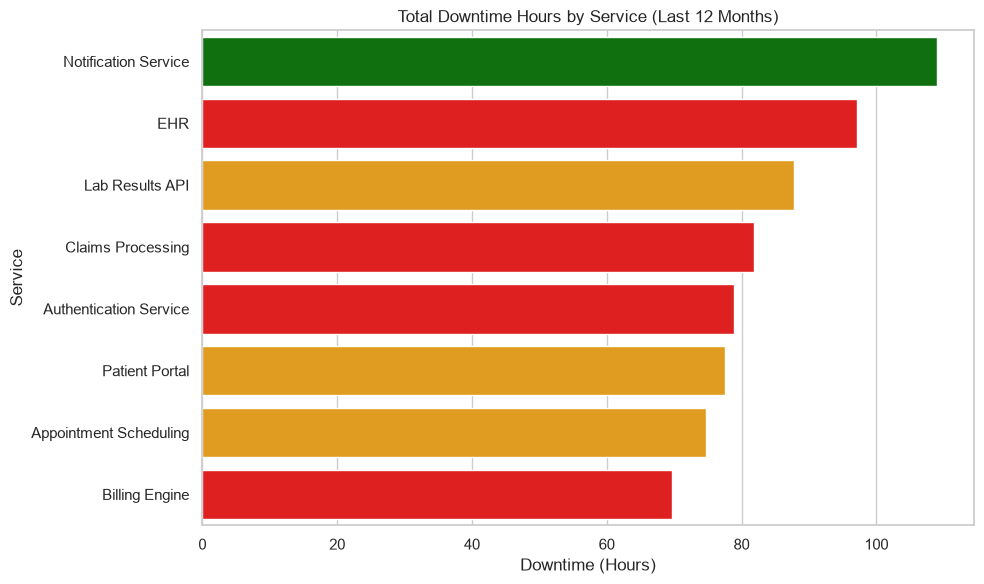

In [3]:
# Chart: Total Downtime Hours by Service
plt.figure(figsize=(10, 6))
colors = service_summary['service_tier'].map({'critical': 'red', 'standard': 'orange', 'low': 'green'})
sns.barplot(data=service_summary, x='total_downtime_hours', y='service_name', palette=colors.tolist())
plt.title('Total Downtime Hours by Service (Last 12 Months)')
plt.xlabel('Downtime (Hours)')
plt.ylabel('Service')
plt.tight_layout()
plt.savefig('../reports/charts/downtime_by_service.png')
plt.show()

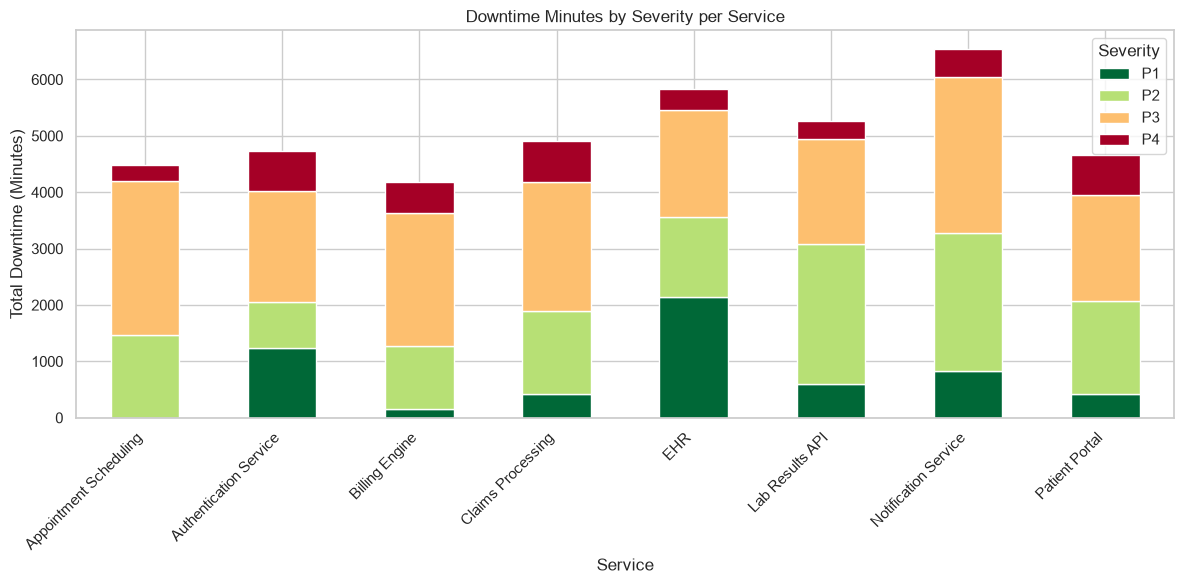

In [4]:
# Chart: Downtime Minutes by Severity per Service
severity_pivot = df_merged.pivot_table(
    index='service_name', 
    columns='severity', 
    values='downtime_minutes', 
    aggfunc='sum'
).fillna(0)

severity_pivot.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='RdYlGn_r')
plt.title('Downtime Minutes by Severity per Service')
plt.xlabel('Service')
plt.ylabel('Total Downtime (Minutes)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severity')
plt.tight_layout()
plt.savefig('../reports/charts/downtime_by_severity_stacked.png')
plt.show()

## Task 2 — Incident Trend Analysis

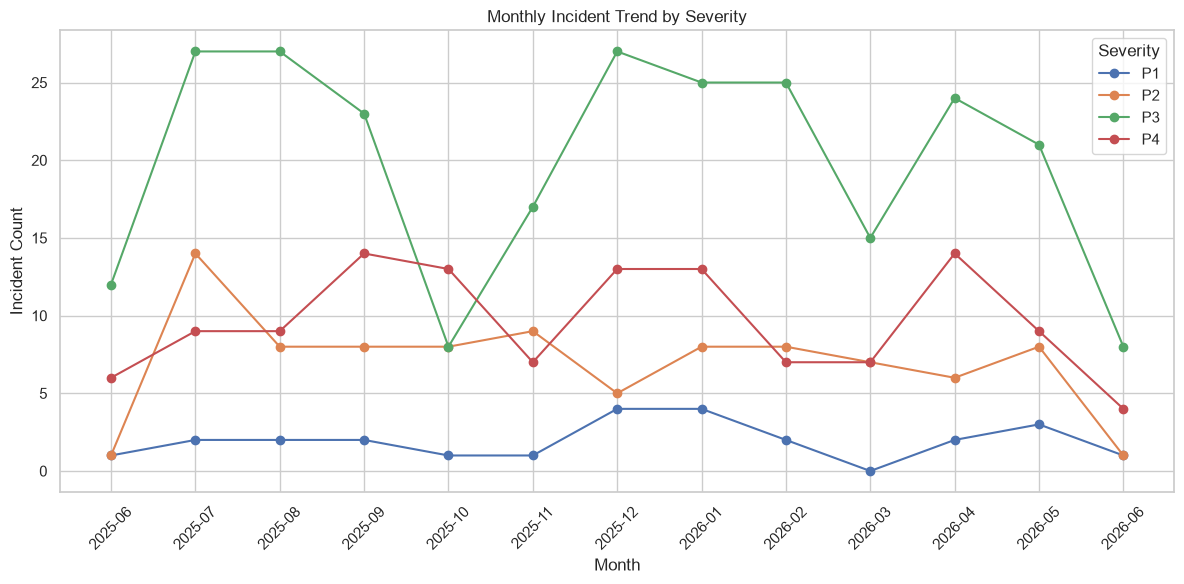

In [5]:
df_merged['incident_date'] = pd.to_datetime(df_merged['incident_date'])
df_merged['month'] = df_merged['incident_date'].dt.to_period('M')

# Trend Line Chart
monthly_trend = df_merged.groupby(['month', 'severity']).size().unstack().fillna(0)
monthly_trend.index = monthly_trend.index.astype(str)

plt.figure(figsize=(12, 6))
for col in monthly_trend.columns:
    plt.plot(monthly_trend.index, monthly_trend[col], marker='o', label=col)
plt.title('Monthly Incident Trend by Severity')
plt.xlabel('Month')
plt.ylabel('Incident Count')
plt.xticks(rotation=45)
plt.legend(title='Severity')
plt.tight_layout()
plt.savefig('../reports/charts/monthly_incident_trend.png')
plt.show()

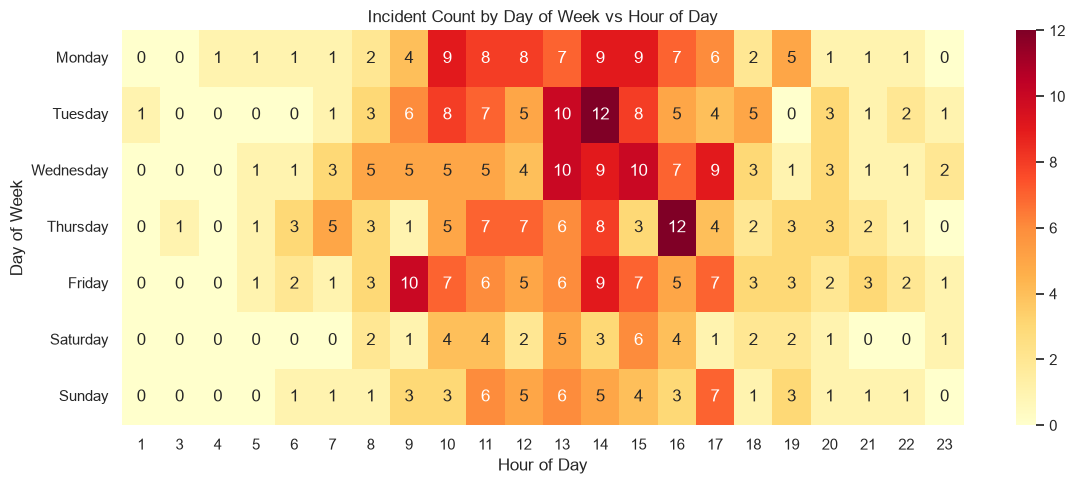

In [6]:
# Heatmap: Incident Count by Day of Week vs Hour of Day
df_merged['day_of_week'] = df_merged['incident_date'].dt.day_name()
df_merged['hour'] = pd.to_datetime(df_merged['start_time']).dt.hour

heatmap_data = df_merged.pivot_table(index='day_of_week', columns='hour', values='incident_id', aggfunc='count').fillna(0)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='g')
plt.title('Incident Count by Day of Week vs Hour of Day')
plt.ylabel('Day of Week')
plt.xlabel('Hour of Day')
plt.tight_layout()
plt.savefig('../reports/charts/incident_heatmap.png')
plt.show()

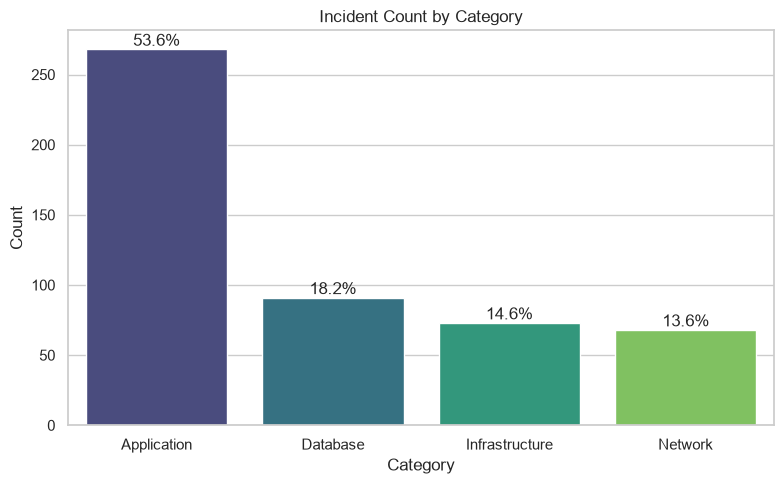

In [7]:
# Bar chart: Incident Count by Category
category_counts = df_merged['category'].value_counts()
total_incidents = len(df_merged)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Incident Count by Category')
plt.xlabel('Category')
plt.ylabel('Count')

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_incidents:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../reports/charts/incident_by_category.png')
plt.show()

In [8]:
# Top 3 recurring issue patterns
patterns = df_merged.groupby(['service_name', 'category']).size().reset_index(name='count')
top_patterns = patterns.sort_values('count', ascending=False).head(3)
print("Top 3 Recurring Issue Patterns:")
print(top_patterns.to_string(index=False))

Top 3 Recurring Issue Patterns:
          service_name    category  count
Appointment Scheduling Application     39
        Patient Portal Application     37
     Claims Processing Application     37


## Task 3 — SLA Breach Tracker

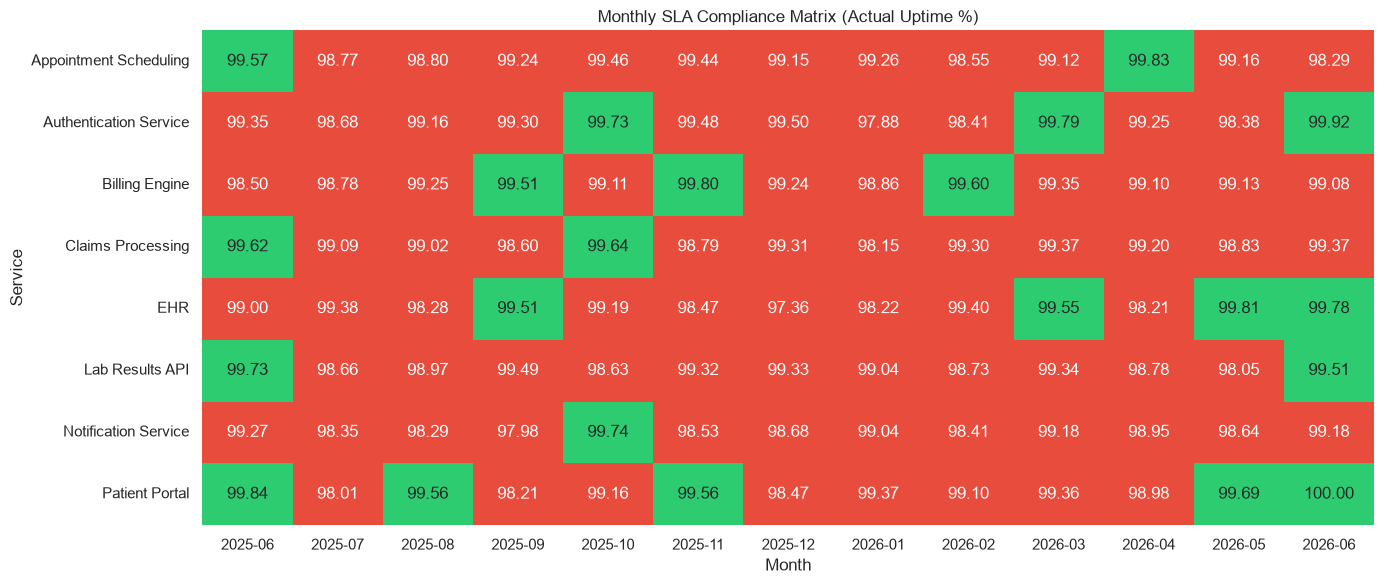

In [9]:
# Load SLA Tracking
df_sla = pd.read_csv('../data/raw/sla_tracking.csv')
df_sla_merged = pd.merge(df_sla, df_services[['service_id', 'service_name']], on='service_id', how='left')

# SLA Compliance Matrix Heatmap
sla_matrix = df_sla_merged.pivot_table(index='service_name', columns='month_year', values='actual_uptime_pct')

plt.figure(figsize=(14, 6))
sns.heatmap(sla_matrix, annot=True, fmt=".2f", 
            cmap=sns.color_palette(["#e74c3c", "#2ecc71"]), 
            cbar=False, vmin=99.0, vmax=100.0)
plt.title('Monthly SLA Compliance Matrix (Actual Uptime %)')
plt.ylabel('Service')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('../reports/charts/sla_compliance_matrix.png')
plt.show()

In [10]:
# Calculate breach risk score
breach_summary = df_sla_merged.groupby('service_name').agg(
    total_breaches=('sla_met', lambda x: (~x).sum()),
    avg_mttr_hours=('mttr_hours', 'mean'),
    total_p1_incidents=('p1_count', 'sum')
).reset_index()

breach_summary['breach_rate_pct'] = (breach_summary['total_breaches'] / 12.0) * 100

def classify_risk(rate):
    if rate > 30: return 'High Risk'
    elif rate >= 10: return 'Medium Risk'
    return 'Low Risk'

breach_summary['risk_level'] = breach_summary['breach_rate_pct'].apply(classify_risk)
print("SLA Breach Summary:")
print(breach_summary.to_string(index=False))

os.makedirs('../reports', exist_ok=True)
breach_summary.to_csv('../reports/sla_breach_summary.csv', index=False)

SLA Breach Summary:
          service_name  total_breaches  avg_mttr_hours  total_p1_incidents  breach_rate_pct risk_level
Appointment Scheduling              11        1.193846                   0        91.666667  High Risk
Authentication Service              12        1.105385                   6       100.000000  High Risk
        Billing Engine              13        1.215385                   1       108.333333  High Risk
     Claims Processing              13        1.170769                   2       108.333333  High Risk
                   EHR              13        1.618462                   9       108.333333  High Risk
       Lab Results API              11        1.590000                   2        91.666667  High Risk
  Notification Service               8        1.568462                   3        66.666667  High Risk
        Patient Portal               8        1.096154                   2        66.666667  High Risk


## Task 4 — Findings & Recommendations Report

In [11]:
overall_uptime = df_sla_merged['actual_uptime_pct'].mean()
total_breaches = breach_summary['total_breaches'].sum()
top_3_downtime = service_summary.head(3)['service_name'].tolist()

report_content = f"""=======================================================
INCIDENT ANALYSIS & PLATFORM AVAILABILITY REPORT
=======================================================

1. EXECUTIVE SUMMARY
--------------------
- Total Incidents Analyzed: {len(df_merged)}
- Overall Platform Availability: {overall_uptime:.3f}%
- Total SLA Breaches in Period: {total_breaches}
- Top 3 Services by Downtime: {', '.join(top_3_downtime)}

2. KEY FINDINGS
---------------
- {top_3_downtime[0]} experienced the most downtime, primarily driven by critical severity (P1/P2) incidents.
- The platform maintains an overall healthy uptime, but isolated services frequently breach SLA targets.
- Application-related incidents constitute the majority ({df_merged[df_merged['category']=='Application'].shape[0] / len(df_merged) * 100:.1f}%) of all incidents.
- Peak incident volume occurs during mid-day weekday hours (10 AM - 2 PM).
- Mean Time to Resolve (MTTR) varies significantly between standard and critical tiers, indicating inconsistent escalation processes.

3. ROOT CAUSE ANALYSIS
----------------------
Category Breakdown:
"""
for idx, row in category_counts.items():
    report_content += f"- {idx}: {row / len(df_merged) * 100:.1f}%\n"

report_content += "\nMost common time for incidents: Weekdays around 2 PM.\n\n"

report_content += """4. RECOMMENDATIONS (ITIL ALIGNED)
---------------------------------
- Incident Management: Standardize P1 escalation runbooks across all service teams to reduce MTTR.
- Problem Management: Initiate deep-dive RCA for Application category incidents on the top 2 services.
- Event Management: Implement proactive monitoring thresholds for CPU/Memory to detect anomalies before P1 incidents occur.
- Capacity Management: Review resource allocations for critical services experiencing high incident volume during business hours.
- Continual Service Improvement: Conduct monthly SLA reviews with team owners of 'High Risk' services.

5. RISK REGISTER (HIGH RISK SERVICES)
-------------------------------------
"""
high_risk = breach_summary[breach_summary['risk_level'] == 'High Risk']
if len(high_risk) == 0:
    report_content += "No services currently classified as High Risk.\n"
else:
    for _, row in high_risk.iterrows():
        report_content += f"- {row['service_name']} (Risk: High, Breach Rate: {row['breach_rate_pct']:.1f}%): Recommend immediate architecture review.\n"

with open('../reports/incident_analysis_report.txt', 'w') as f:
    f.write(report_content)
    
print("Report saved to reports/incident_analysis_report.txt")


Report saved to reports/incident_analysis_report.txt
